### Build models & compare classifiers

- **Task A** — cancer vs normal: *given an unseen person's serum cfRNA, are they a breast-cancer patient or a healthy control?*
- **Task B** — recurrence vs non-recurrence: *given an unseen breast-cancer patient, do they have recurrent disease?* (at the donor level)


In [1]:
# Imports

import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, accuracy_score, confusion_matrix,
)

warnings.filterwarnings("ignore") 
RANDOM_STATE = 42

In [2]:
# Config

FOLDER       = Path("processed")
RESULTS      = Path("results")
GENESET_PATH = None
SELECT_K     = None 
RESULTS.mkdir(exist_ok=True)

In [3]:
# Load data / checks

d = pickle.load(open(FOLDER / "cancer_vs_normal.pkl", "rb"))

print("keys:", list(d.keys()))
print("X shape (samples x genes):", d["X"].shape)
print("label counts:", d["y"].value_counts().to_dict())
print("number of donors/groups:", d["group"].nunique())
print("samples per test fold:", d["fold"].value_counts().sort_index().to_dict())
d["X"].iloc[:3, :5] 

keys: ['X', 'y', 'group', 'fold', 'genes', 'n_splits']
X shape (samples x genes): (128, 42536)
label counts: {1: 96, 0: 32}
number of donors/groups: 76
samples per test fold: {0: 43, 1: 40, 2: 45}


gene,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460
S01,3.012856,3.835863,0.000000,2.850470,5.130873
S02,5.945111,5.597653,0.000000,1.686429,5.202745
S03,5.888887,5.941470,4.587377,3.713802,5.831032


In [4]:
# Pick genes

def subset_genes(available, geneset_path):
    if geneset_path is None:
        return list(available)
    requested = [ln.strip() for ln in open(geneset_path)
                 if ln.strip() and not ln.startswith("#")]
    avail = set(available)
    keep = [g for g in requested if g in avail]
    print(f"  gene set: {len(keep)}/{len(requested)} requested genes found")
    return keep

keep = subset_genes(d["genes"], GENESET_PATH)
print("Used genes:", len(keep))

Used genes: 42536


### Seven models

In [5]:
def build_models(select_k):
    def pipe(*clf_step):
        head = [("scale", StandardScaler())]
        return Pipeline(head + list(clf_step))

    return {
        "logreg_l2": pipe(("clf", LogisticRegression(
            penalty="l2", C=1.0, class_weight="balanced", max_iter=2000, solver="lbfgs"))),
        "logreg_l1": pipe(("clf", LogisticRegression(
            penalty="l1", C=1.0, class_weight="balanced", max_iter=5000, solver="liblinear"))),
        "logreg_elasticnet": pipe(("clf", LogisticRegression(
            penalty="elasticnet", l1_ratio=0.5, C=1.0, class_weight="balanced",
            max_iter=5000, solver="saga"))),
        "svm_rbf": pipe(("clf", SVC(
            kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
            probability=True, random_state=RANDOM_STATE))),
        "knn": pipe(("clf", KNeighborsClassifier(n_neighbors=7))),
        "random_forest": pipe(("clf", RandomForestClassifier(
            n_estimators=400, class_weight="balanced_subsample",
            n_jobs=-1, random_state=RANDOM_STATE))),
        "hist_gbm": pipe(("clf", HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=400, l2_regularization=1.0,
            random_state=RANDOM_STATE))),
    }

list(build_models(SELECT_K).keys())

['logreg_l2',
 'logreg_l1',
 'logreg_elasticnet',
 'svm_rbf',
 'knn',
 'random_forest',
 'hist_gbm']

### Cross-validation (train on 2 folds, predict the 3rd)

In [6]:
X    = d["X"][keep].values
y    = d["y"].values.astype(int)
fold = d["fold"].values
n_splits = int(d["n_splits"])

one_model = lambda: build_models(SELECT_K)["logreg_l2"]
oof = np.full(len(y), np.nan)
per_fold_auc = []
for k in range(n_splits):
    tr, te = fold != k, fold == k               
    model = one_model().fit(X[tr], y[tr])  
    oof[te] = model.predict_proba(X[te])[:, 1]   
    per_fold_auc.append(roc_auc_score(y[te], oof[te]))
    print(f"fold {k}: trained - {tr.sum()}, tested - {te.sum()}, AUC = {per_fold_auc[-1]:.3f}")

print("pooled OOF AUC:", round(roc_auc_score(y, oof), 3))

fold 0: trained - 85, tested - 43, AUC = 0.980
fold 1: trained - 88, tested - 40, AUC = 0.997
fold 2: trained - 83, tested - 45, AUC = 1.000
pooled OOF AUC: 0.993


In [7]:
def scores_of(model, X):
    return model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") \
        else model.decision_function(X)

def metric_row(name, y, scores, preds, n_feat, per_fold_auc):
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    return {
        "model": name, "n_features": n_feat,
        "auc_mean_fold": float(np.mean(per_fold_auc)),
        "auc_pooled": float(roc_auc_score(y, scores)),
        "pr_auc_pooled": float(average_precision_score(y, scores)),
        "accuracy": float(accuracy_score(y, preds)),
        "balanced_acc": float(balanced_accuracy_score(y, preds)),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }

def oof_predict(make_model, X, y, fold, n_splits): # out-of-fold
    oof_s = np.full(len(y), np.nan)
    oof_p = np.full(len(y), np.nan)
    aucs = []
    for k in range(n_splits):
        tr, te = fold != k, fold == k
        m = make_model().fit(X[tr], y[tr])
        oof_s[te] = scores_of(m, X[te])
        oof_p[te] = m.predict(X[te])
        aucs.append(roc_auc_score(y[te], oof_s[te]))
    return oof_s, oof_p.astype(int), aucs

### Results on Task A (cancer vs normal)

In [8]:
rows, oof_store = [], {}
n_feat = X.shape[1] if SELECT_K is None else min(SELECT_K, X.shape[1])

for name in build_models(SELECT_K):
    s, p, aucs = oof_predict(lambda n=name: build_models(SELECT_K)[n], X, y, fold, n_splits)
    rows.append(metric_row(name, y, s, p, n_feat, aucs))
    oof_store[name] = s

tableA = pd.DataFrame(rows).sort_values("auc_pooled", ascending=False).reset_index(drop=True)
tableA

,model,n_features,auc_mean_fold,auc_pooled,pr_auc_pooled,accuracy,balanced_acc,tn,fp,fn,tp
0,logreg_l1,42536,1.000000,1.000000,1.000000,1.000000,1.000000,32,0,0,96
1,logreg_elasticnet,42536,1.000000,1.000000,1.000000,0.968750,0.979167,32,0,4,92
2,random_forest,42536,1.000000,1.000000,1.000000,0.867188,0.734375,15,17,0,96
3,logreg_l2,42536,0.992260,0.993164,0.997845,0.937500,0.895833,26,6,2,94
4,svm_rbf,42536,0.984848,0.988281,0.996040,0.765625,0.531250,2,30,0,96
5,hist_gbm,42536,0.977778,0.964844,0.978261,0.984375,0.979167,31,1,1,95
6,knn,42536,0.800563,0.787435,0.887973,0.765625,0.708333,19,13,17,79


### Results on Task B (recurrence vs non-recurrence)

In [9]:
db = pickle.load(open(FOLDER / "recurrence.pkl", "rb"))
keepB = subset_genes(db["genes"], GENESET_PATH)
Xb, yb = db["X"][keepB].values, db["y"].values.astype(int)
foldb, groupsb = db["fold"].values, db["group"].values
n_splits_b = int(db["n_splits"])

def donor_level_auc(y, scores, groups):
    g = pd.DataFrame({"y": y, "s": scores, "g": groups}).groupby("g").agg(
        y=("y", "first"), s=("s", "mean"))
    return float(roc_auc_score(g["y"], g["s"])) if g["y"].nunique() > 1 else np.nan

rowsB, oof_storeB = [], {}
n_featB = Xb.shape[1] if SELECT_K is None else min(SELECT_K, Xb.shape[1])
for name in build_models(SELECT_K):
    s, p, aucs = oof_predict(lambda n=name: build_models(SELECT_K)[n],
                             Xb, yb, foldb, n_splits_b)
    r = metric_row(name, yb, s, p, n_featB, aucs)
    r["auc_donor"] = donor_level_auc(yb, s, groupsb) 
    rowsB.append(r); oof_storeB[name] = s

tableB = pd.DataFrame(rowsB).sort_values("auc_donor", ascending=False).reset_index(drop=True)
tableB[["model", "auc_pooled", "auc_donor", "pr_auc_pooled", "balanced_acc"]]

,model,auc_pooled,auc_donor,pr_auc_pooled,balanced_acc
0,logreg_elasticnet,0.564601,0.602941,0.362730,0.487395
1,logreg_l2,0.546218,0.576471,0.336246,0.500000
2,hist_gbm,0.525735,0.567647,0.369068,0.487395
3,random_forest,0.533088,0.532353,0.349687,0.500000
4,logreg_l1,0.476891,0.497059,0.320370,0.477941
5,svm_rbf,0.413866,0.458824,0.271083,0.500000
6,knn,0.361345,0.336765,0.262684,0.470588


### External validation cohort

In [10]:
val = pickle.load(open(FOLDER / "validation.pkl", "rb"))

def external_eval(task, train_pkl, geneset_path, select_k):
    dt = pickle.load(open(FOLDER / train_pkl, "rb"))
    keep = subset_genes(dt["genes"], geneset_path)
    Xtr, ytr = dt["X"][keep].values, dt["y"].values.astype(int)
    Xv = val["X"][keep].values
    if task == "A":
        yv, mask = val["y_cancer"].values.astype(int), np.ones(len(val["X"]), bool)
    else:
        raw = val["y_recur"].values
        mask = ~pd.isna(raw); yv = raw[mask].astype(int); Xv = Xv[mask]
    out = []
    fitted_models = {}
    for name, mk in build_models(select_k).items():
        m = mk.fit(Xtr, ytr)
        fitted_models[name] = m
        sv = scores_of(m, Xv)
        out.append({"model": name,
                    "ext_auc": roc_auc_score(yv, sv) if len(set(yv)) > 1 else np.nan,
                    "ext_pr_auc": average_precision_score(yv, sv)})
    return pd.DataFrame(out).sort_values("ext_auc", ascending=False).reset_index(drop=True), fitted_models #added

print("External — Task A:")
#extA = external_eval("A", "cancer_vs_normal.pkl", GENESET_PATH, SELECT_K)
extA, fitted_models_A= external_eval("A", "cancer_vs_normal.pkl", GENESET_PATH, SELECT_K)
display(extA)
print("External — Task B (cancer samples with a recurrence label only):")
#extB = external_eval("B", "recurrence.pkl", GENESET_PATH, SELECT_K)
extB, fitted_models_B = external_eval("B", "recurrence.pkl", GENESET_PATH, SELECT_K)
display(extB)

# save the models as pickle files
with open("results/taskA_fitted_models.pkl", "wb") as f:
    pickle.dump(fitted_models_A, f)
with open("results/taskB_fitted_models.pkl", "wb") as f:
    pickle.dump(fitted_models_B, f)


External — Task A:


,model,ext_auc,ext_pr_auc
0,logreg_l2,0.736021,0.798346
1,svm_rbf,0.707136,0.764998
2,logreg_elasticnet,0.687519,0.719842
3,random_forest,0.643960,0.683529
4,knn,0.578622,0.586659
5,hist_gbm,0.560550,0.548495
6,logreg_l1,0.544640,0.567868


External — Task B (cancer samples with a recurrence label only):


,model,ext_auc,ext_pr_auc
0,svm_rbf,0.580000,0.148399
1,logreg_elasticnet,0.526667,0.132171
2,knn,0.506667,0.112500
3,logreg_l1,0.505000,0.141679
4,hist_gbm,0.463333,0.100849
5,logreg_l2,0.451667,0.095142
6,random_forest,0.419167,0.094340


### Batch-correct validation to PNAS reference

In [11]:
from inmoose.pycombat import pycombat_seq

DATA = Path("data")

def _read_counts_no_header(path, sample_names):
    """PNAS BC counts: no header row; columns map positionally to sample_names."""
    m = pd.read_csv(path, sep="\t", header=None, index_col=0)
    m.columns = sample_names
    m.index.name = "gene"
    return m.T  # samples x genes

def _read_counts_with_header(path):
    """Normal / validation counts: header present, gene-id column unlabeled."""
    m = pd.read_csv(path, sep="\t", index_col=0)
    m.index.name = "gene"
    return m.T  # samples x genes

def batch_correct_validation(counts_pnas: pd.DataFrame,
                             counts_val: pd.DataFrame) -> pd.DataFrame:
    PNAS_BATCH, VAL_BATCH = "pnas", "val"
    Y_combined = pd.concat([counts_pnas.T, counts_val.T], axis=1).round().astype(int)
    batch = [PNAS_BATCH] * len(counts_pnas) + [VAL_BATCH] * len(counts_val)
    corrected = pycombat_seq(Y_combined, batch, ref_batch=PNAS_BATCH)
    val_cols = corrected.columns[len(counts_pnas):]
    corrected_val = corrected[val_cols].T   # samples x genes
    return np.log2(corrected_val + 1)

# BC counts file has 96 columns — use only the 96 BC sample names from db["X"]
bc_sample_names = db["X"].index.tolist()   # S01..S96
bc_counts     = _read_counts_no_header(DATA / "pnas_readcounts_96_nodup.txt", bc_sample_names)
normal_counts = _read_counts_with_header(DATA / "pnas_normal_readcounts.txt")
genes_in_counts = bc_counts.columns.intersection(normal_counts.columns)
pnas_counts = pd.concat(
    [bc_counts[genes_in_counts], normal_counts[genes_in_counts]], axis=0
).reindex(columns=keep, fill_value=0)

# Load validation counts, aligned to the same samples and genes
val_counts_raw = _read_counts_with_header(DATA / "validation_exon_readcounts")
val_counts = (val_counts_raw
              .reindex(index=val["X"].index, fill_value=0)
              .reindex(columns=keep, fill_value=0))

X_val_corrected = batch_correct_validation(pnas_counts, val_counts)

print(f"Validation: {val['X'].shape} -> batch-corrected {X_val_corrected.shape}")

Validation: (161, 42536) -> batch-corrected (161, 42536)


### External validation on batch-corrected cohort

In [12]:
def external_eval_corrected(task, train_pkl, geneset_path, select_k, X_val_corr):
    dt = pickle.load(open(FOLDER / train_pkl, "rb"))
    keep = subset_genes(dt["genes"], geneset_path)
    Xtr, ytr = dt["X"][keep].values, dt["y"].values.astype(int)
    Xv = X_val_corr[keep].values
    if task == "A":
        yv = val["y_cancer"].values.astype(int)
    else:
        raw = val["y_recur"].values
        mask = ~pd.isna(raw)
        yv = raw[mask].astype(int)
        Xv = Xv[mask]
    out = []
    for name, mk in build_models(select_k).items():
        m = mk.fit(Xtr, ytr)
        sv = scores_of(m, Xv)
        out.append({
            "model": name,
            "ext_auc_corrected": roc_auc_score(yv, sv) if len(set(yv)) > 1 else np.nan,
            "ext_pr_auc_corrected": float(average_precision_score(yv, sv)),
        })
    return pd.DataFrame(out)

extA_corr = external_eval_corrected("A", "cancer_vs_normal.pkl", GENESET_PATH, SELECT_K, X_val_corrected)
extB_corr = external_eval_corrected("B", "recurrence.pkl",       GENESET_PATH, SELECT_K, X_val_corrected)

for label, raw, corr in [("Task A — cancer vs normal", extA, extA_corr),
                          ("Task B — recurrence (cancer samples only)", extB, extB_corr)]:
    merged = (raw[["model", "ext_auc"]]
              .merge(corr[["model", "ext_auc_corrected"]], on="model"))
    merged["delta"] = (merged["ext_auc_corrected"] - merged["ext_auc"]).round(4)
    merged = merged.sort_values("ext_auc_corrected", ascending=False).reset_index(drop=True)
    print(f"\n{label}")
    display(merged)


Task A — cancer vs normal


,model,ext_auc,ext_auc_corrected,delta
0,svm_rbf,0.707136,0.730615,0.0235
1,logreg_l2,0.736021,0.652765,-0.0833
2,logreg_elasticnet,0.687519,0.648594,-0.0389
3,knn,0.578622,0.602796,0.0242
4,random_forest,0.643960,0.601637,-0.0423
5,logreg_l1,0.544640,0.568273,0.0236
6,hist_gbm,0.560550,0.500000,-0.0605



Task B — recurrence (cancer samples only)


,model,ext_auc,ext_auc_corrected,delta
0,svm_rbf,0.580000,0.601667,0.0217
1,logreg_l1,0.505000,0.491667,-0.0133
2,hist_gbm,0.463333,0.463333,0.0000
3,knn,0.506667,0.453333,-0.0533
4,logreg_elasticnet,0.526667,0.406667,-0.1200
5,logreg_l2,0.451667,0.401667,-0.0500
6,random_forest,0.419167,0.386667,-0.0325


### Plot the comparison

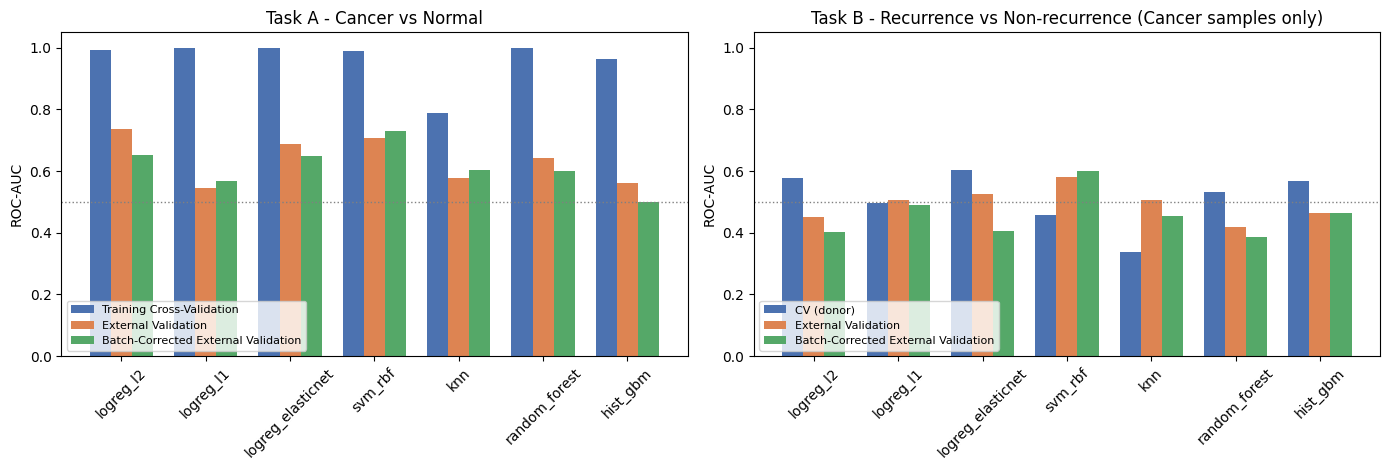

In [13]:
import matplotlib.pyplot as plt

def plot_panel(ax, title, models, cv_vals, cv_label, ext_vals, ext_label,
               ext_corr_vals=None, ext_corr_label=None):
    n_bars = 3 if ext_corr_vals is not None else 2
    w = 0.25 if n_bars == 3 else 0.38
    x = np.arange(len(models))
    offsets = [-w, 0, w] if n_bars == 3 else [-w/2, w/2]

    ax.axhline(0.5, color="grey", linestyle=":", linewidth=1)
    ax.bar(x + offsets[0], cv_vals,  w, label=cv_label,  color="#4C72B0")
    ax.bar(x + offsets[1], ext_vals, w, label=ext_label, color="#DD8452")
    if ext_corr_vals is not None:
        ax.bar(x + offsets[2], ext_corr_vals, w, label=ext_corr_label, color="#55A868")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="center")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower left")


order = list(build_models(SELECT_K).keys())
a_cv       = tableA.set_index("model").loc[order, "auc_pooled"].values
a_ext      = extA.set_index("model").loc[order, "ext_auc"].values
a_ext_corr = extA_corr.set_index("model").loc[order, "ext_auc_corrected"].values
b_cv       = tableB.set_index("model").loc[order, "auc_donor"].values
b_ext      = extB.set_index("model").loc[order, "ext_auc"].values
b_ext_corr = extB_corr.set_index("model").loc[order, "ext_auc_corrected"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))
plot_panel(ax1, "Task A - Cancer vs Normal", order,
           a_cv, "Training Cross-Validation", a_ext, "External Validation", a_ext_corr, "Batch-Corrected External Validation")
plot_panel(ax2, "Task B - Recurrence vs Non-recurrence (Cancer samples only)", order,
           b_cv, "CV (donor)",  b_ext, "External Validation", b_ext_corr, "Batch-Corrected External Validation")
fig.tight_layout()
fig.savefig(RESULTS / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Save results

In [14]:
tableA.to_csv(RESULTS / "compare_taskA.csv", index=False)
tableB.to_csv(RESULTS / "compare_taskB.csv", index=False)

oofA = pd.DataFrame(oof_store, index=d["X"].index)
oofA.insert(0, "y", y); oofA.insert(1, "group", d["group"].values)
oofA.to_csv(RESULTS / "oof_taskA.csv")

oofB = pd.DataFrame(oof_storeB, index=db["X"].index)
oofB.insert(0, "y", yb); oofB.insert(1, "group", groupsb)
oofB.to_csv(RESULTS / "oof_taskB.csv")

print("saved to", RESULTS.resolve())
sorted(p.name for p in RESULTS.glob("*.csv"))

saved to /Users/coteparker/homework/CSE 283/BREAST-CANCER-CLASSIFICATION/results


['compare_taskA.csv',
 'compare_taskB.csv',
 'feature_selection_taskA.csv',
 'feature_selection_taskB.csv',
 'oof_taskA.csv',
 'oof_taskB.csv']

### Feature selection strategies

| Approach | Description |
|----------|-------------|
| **Biologically-informed** | All unique genes in `table_s5_genes` (Table S5 literature associations) |
| **Differential expression** | Welch's t-test between groups, BH FDR < 0.05 — done separately for Task A (cancer vs normal) and Task B (recurrence vs non-recurrence) |
| **Most variable** | Top-*N* genes by training-set variance across PNAS samples |

#### Biologically-Informed (Bio)

In [15]:
import mygene
import warnings

table_s5_genes = {
    "H/I": ["HOXB13", "IL17BR"],
    "PAM50": [
        "UBE2T","BIRC5","NUF2","CDC6","CCNB1","TYMS","MYBL2","CEP55","MELK","NDC80",
        "RRM2","UBE2C","CENPF","PTTG1","EXO1","ORC6L","ANLN","CCNE1","CDC20","MKI67",
        "KIF2C","ACTR3B","MYC","EGFR","KRT5","PHGDH","CDH3","MIA","KRT17","FOXC1",
        "SFRP1","KRT14","ESR1","SLC39A6","BAG1","MAPT","PGR","CXXC5","MLPH","BCL2",
        "MDM2","NAT1","FOXA1","BLVRA","MMP11","GPR160","FGFR4","GRB7","TMEM45B","ERBB2",
    ],
    "Oncotype DX": [
        "BAG1","BCL2","CCNB1","CD68","SCUBE2","CTSL2","ESR1","GRB7","GSTM1","ERBB2",
        "MKI67","MYBL2","PGR","AURKA","MMP11","BIRC5","ACTB","GAPDH","GUSB","RPLP0","TFRC",
    ],
    "BreastOncPx": [
        "BUB1","CCNB1","CENPA","DC13","DIAPH3","MELK","MYBL2","ORC6L","PKMYT1","PRR11",
        "RACGAP1","RFC4","TK1","UBE2S",
    ],
    "MammaPrint": [
        "BBC3","EGLN1","TGFB3","ESM1","IGFBP5","FGF18","SCUBE2","WISP1","FLT1","HRASLS",
        "STK32B","RASSF7","DCK","MELK","EXT1","GNAZ","EBF4","MTDH","PITRM1","QSCN6L1",
        "CCNE2","ECT2","CENPA","LIN9","KNTC2","MCM6","NUSAP1","ORC6L","TSPYL5","RUNDC1",
        "PRC1","RFC4","RECQL5","CDCA7","DTL","COL4A2","GPR180","MMP9","GPR126","RTN4RL1",
        "DIAPH3","CDC42BPA","PALM2","ALDH4A1","LPCAT1","LPCAT2","LPCAT4","OXCT1","PECI",
        "GMPS","GSTM3","SLC2A3","C9orf30","ZNF533","C16orf61","SERF1A","C20orf46","LGP2",
        "NMU","UCHL5","JHDM1D","AP2B1","MS4A7","RAB6B",
    ],
    "HDPP": [
        "ABCD4","ADD3","AFP","ALAS2","ANPEP","ARHGAP19","ARIH2","ATOH8","ATP8B2","AXIN2",
        "BIN3","BMP4","CASP6","CD3D","CD55","CD69","CDON","CFL2","CLCN7","CLSTN3","COL8A1",
        "COLEC12","COMP","CRMP1","CX3CR1","CXCR4","DCBLD1","DPYSL2","EDNRB","ELMO3","EPB41",
        "ETS1","FAIM3","FAM46A","FAM89A","FGF2","FLNC","FYN","GAS7","GLRX2","GPC3","GPR172A",
        "GPX3","GRB7","GRHL1","GYPC","HEMGN","HHIP","HMHA1","HSPBP1","IL17RD","INHBA","IRF6",
        "ITGA4","ITM2A","KIRREL","KLF9","KPNA3","LAD1","LAT","LONRF1","LPGAT1","LTBP1",
        "LTBP4","MAP4","MAP7D3","MARCH8","MED19","MFAP4","MLXIPL","MTHFR","NDN","NLGN2",
        "NUDT9","PDE2A","PELI2","PEX11B","PGM2L1","PIM1","PKP3","PLAC8","PLAU","PPP1R14A",
        "PPP5C","PRKCA","PTPRCAP","PXDN","RAC2","RASIP1","RBM5","RBP4","RFT1","RNF166",
        "S100A11","S100B","SDPR","SEMA6A","SEMA7A","SENP5","SH3BP5","SH3KBP1","SH3YL1",
        "SLC16A7","SLC25A42","SLC38A5","SLK","SNCA","SOCS1","SOX10","SPTBN2","ST3GAL2",
        "ST6GALNAC6","STARD4","STAT5A","STON2","STXBP1","TCF7","TF","TGFBR3","TLE4",
        "TMEFF1","TSPAN7","UBE2G1","WDHD1","ZAP70","ZNF276","ZNF281","ZNF609","ZNF690",
    ],
    "HTICS": [
        "AURKB","CCNA2","SCRN1","NPY","ATP7B","CHAF1B","CCNB1","CLDN8","NRP1","CCR2",
        "C1QB","CD74","VCAM1","CD180","ITGB2","CD72","ST8SIA4",
    ],
    "eXagen BC": ["CYP2D6","CYP24","PDCD6IP","BIRC5","NR1D1","SMARCE1"],
    "Mammostra t": ["TP53","NDRG1","CEACAM5","SLC7A2","SLC7A5","TRMT2A"],
    "ProEx Br": ["E2F1","RASA1","PSMB1"],
    "Rotterdam": [
        "CLN8","GOLM1","YIF1A","IL18","CBX3","DUSP4","PPP1CC","ABLIM1","TNFSF13","TMEM8A",
        "C3","NCAPG2","MAP4","TACC2","SMC4","ORC3","ATAD2","CD44","PLK1","CNKSR1","FEN1",
        "FKBP2","KPNA2","GFOD2","AP2A2","NEURL","SUPT16H","ZFP36L2","ARHGDIB","PSMC2",
        "ZCCHC8","SLC35A1","CCNE2","POLQ","CAPN2","UCKL1","LST1","ACACB","EEF1A2","NEFL",
        "MMP23B","GTSE1","COL2A1","GAS2","FUT3","TNFSF10","PARP4","BCL2L14","CEP57",
    ],
    "MapQuantDx": ["UBE2C","KPNA2","TPX2","FOXM1","STK6","CCNA2","BIRC5","MYBL2"],
    "IGS": [
        "DPF2","CASP8","BCL2","SCGN","SWAP70","CD59","LRP2","PLP2","MAPK14","CXCL2","MMP7",
        "MGP","FLNB","HSPC163","TICAM2","KDELR3","GNPDA1","DBR1","GAPD","LDHA","MR1","LARS",
        "GTPBP1","PRSS16","WFDC2","AIM1","DHRS6","DHRS4","CYP4V2","ICMT","DNMT3A","HNMT",
        "METTL7A","VIL2","TPD52","ARPC5","NSF","RAD23B","SRP54","HSPA2","THAP2","CIRBP",
        "SNRPN","DUSP10","SSR1","ERBB4","EMP1","CHPT1","LRPAP1","CSTF1","KLHL20","DNAJC13",
        "APLP2","DNAJB1","NEBL","SH3BGRL","NUDT5","GABARAPL1","MAPT","DCBLD1","STK39","PAK2",
        "CSNK2A1","ERN1","SGK3","WEE1","MAST4","NUP37","CLTC","COPB2","SLC25A25","PDE8A",
        "STAM","TUBB","SNX6","RAB23","PLAA","STC2","LTF","ATXN3","GSK3B","KLF10","ELL2",
        "ZBTB20","ETS1","SERTAD1","MAFF","SFPQ","CITED4","CEBPD","EIF4E2","HS2ST1","AGPS",
        "PGK1","ATIC","ETNK1","ALG2","CNOT4","RNF8","PSMA5",
    ],
    "NuvoSelect": [
        "FCGR3A","PLD3","CCNL2","SEC61A1","KPNA2","NFAT5","HN1","SLC35B1","NME1","EFEMP1",
        "RALGDS","SURF4","KRT13","GSR","ATF5","PTPRC","ACLY","FAAH","RTKN","STOML1","MGST1",
        "CREM","ANXA8","TFRC","TCEB3","APH1A","PRPSAP1","NME2","TBPL1","GTF2H3","SLC7A10",
        "NDP","SCARA3","APOE",
    ],
    "Protein expression - cyclins/apoptosis": [
        "MKI67","CCNA1","CCNA2","CCNB1","CCNB2","CCND1","CCND2","CCND3","CCNE1","CCNE2",
        "CCNF","CCNG1","CCNG2","CCNH","CCNI","CCNK","CCNL1","CCNL2","CCNO","CCNT1","CCNT2",
        "PLAU","TP53","CDKN1A","CASP9","BAK1","BAD","BCL2L11","BCL2A1","BCL2L1","CASP4",
        "AIFM1","BCL2","CASP3","SIVA1","BAX","PAWR","BRCA1","BRCA2",
    ],
    "Protein expression - hormone receptors": ["ESR1","ESR2","PGR","AR"],
    "Protein expression - TOP2A/EGFR": ["TOP2A","EGFR"],
    "Protein expression - FOXA1": ["FOXA1"],
    "Protein expression - PIP": ["PIP"],
    "Protein expression - MCM2": ["MCM2"],
    "Protein expression - NME1": ["NME1"],
    "Protein expression - PRKCA": ["PRKCA"],
    "Protein expression - GRB7/HER2": ["GRB7","HER2"],
    "DNA sequence - methylation panel": [
        "AATK","USP32","ACTB","APOL1","CD74","MBD6","GNB2","CTSD","KRT18","PLEC","TSPAN14",
        "YWHAZ","ZBTB33","COL1A1","FMNL3","CYB5R3","TXNIP","DCLK1","COL3A1","ELF3","SLC39A6",
        "MGP","STC2","RNF11","TAX1BP1","MALAT1",
    ],
    "DNA sequence - methylation (tumor suppressors)": [
        "BRCA1","APC","RASSF1A","WIF1","MGMT","MAL","CDH13","RARB","CDKN2A","TP73","GSTP1","CDH1",
    ],
    "DNA sequence - APOBEC3 family": [
        "APOBEC3A","APOBEC3B","APOBEC3C","APOBEC3D","APOBEC3F","APOBEC3G","APOBEC3H",
    ],
    "DNA sequence - FGFR2/TOX3/MAP3K1/LSP1": ["FGFR2","TOX3","MAP3K1","LSP1"],
    "DNA sequence - TP53": ["TP53"],
    "DNA sequence - BRCA2": ["BRCA2"],
    "DNA sequence - PTEN": ["PTEN"],
    "DNA sequence - PIK3CA": ["PIK3CA"],
    "DNA sequence - CCND2/RARB/TWIST1": ["CCND2","RARB","TWIST1"],
    "DNA sequence - KRAS/NRAS": ["KRAS","NRAS"],
    "RNA expression - MALAT1": ["MALAT1"],
    "RNA expression - H19": ["H19"],
    "RNA expression - MEG3": ["MEG3"],
    "RNA expression - GAS5": ["GAS5"],
    "RNA expression - BTG3": ["BTG3"],
    "RNA expression - ABCB10": ["ABCB10"],
    "RNA expression - TWIST2": ["TWIST2"],
    "RNA expression - TWISTNB": ["TWISTNB"],
    "RNA expression - WDR5": ["WDR5"],
    "RNA expression - PVRL4": ["PVRL4"],
    "RNA expression - DLC1/CDK6": ["DLC1","CDK6"],
    "RNA expression - INPP4B": ["INPP4B"],
    "RNA expression - CCNE1": ["CCNE1"],
    "RNA expression - PTPN13": ["PTPN13"],
    "RNA expression - EPS15": ["EPS15"],
}

all_bio_symbols = sorted({g for genes in table_s5_genes.values() for g in genes})
print(f"Unique gene symbols in table_s5_genes: {len(all_bio_symbols)}")

mg = mygene.MyGeneInfo()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hits = mg.querymany(all_bio_symbols, scopes="symbol", fields="ensembl.gene",
                        species="human", verbose=False)

available_genes = set(keep)
bio_ensembl = set()
for h in hits:
    if "ensembl" not in h:
        continue
    e = h["ensembl"]
    ids = [x["gene"] for x in e] if isinstance(e, list) else [e["gene"]]
    bio_ensembl.update(g for g in ids if g in available_genes)

bio_genes = sorted(bio_ensembl)
print(f"Mapped to Ensembl and found in training data: {len(bio_genes)} genes")

Unique gene symbols in table_s5_genes: 564
Mapped to Ensembl and found in training data: 515 genes


#### Differential expression gene selection

In [16]:
from scipy import stats
from scipy.stats import false_discovery_control

FDR_THRESH = 0.05

def dge_genes(X_df, y_arr, fdr_thresh=FDR_THRESH):
    group0 = X_df.values[y_arr == 0]
    group1 = X_df.values[y_arr == 1]
    _, p_vals = stats.ttest_ind(group0, group1, equal_var=False, axis=0)
    fdr = false_discovery_control(p_vals, method="bh")
    return [g for g, q in zip(X_df.columns, fdr) if q < fdr_thresh]

# Task A: cancer (1) vs normal (0)
Xa_df = d["X"][keep]
dge_A = dge_genes(Xa_df, d["y"].values)
print(f"DGE Task A (cancer vs normal, FDR<{FDR_THRESH}): {len(dge_A)} genes")

# Task B: recurrence (1) vs non-recurrence (0) — BC samples only
Xb_df = db["X"][keep]
dge_B = dge_genes(Xb_df, db["y"].values)
print(f"DGE Task B (recurrence,       FDR<{FDR_THRESH}): {len(dge_B)} genes")

DGE Task A (cancer vs normal, FDR<0.05): 1889 genes
DGE Task B (recurrence,       FDR<0.05): 6 genes


#### Most variable genes

In [17]:
variances = d["X"][keep].var(axis=0)
var_500  = variances.nlargest(500).index.tolist()
var_1000 = variances.nlargest(1000).index.tolist()
print(f"Top-500  most variable genes selected")
print(f"Top-1000 most variable genes selected")

Top-500  most variable genes selected
Top-1000 most variable genes selected


#### Comparison across feature sets

In [18]:
def eval_feature_set(label, gene_list, task="A"):
    if task == "A":
        train_pkl, yv_raw = d, val["y_cancer"].values.astype(int)
        Xv_full = val["X"]
    else:
        train_pkl, yv_raw = db, val["y_recur"].values
        mask = ~pd.isna(yv_raw)
        yv_raw = yv_raw[mask].astype(int)
        Xv_full = val["X"].iloc[mask]

    # intersect requested genes with what's actually in both train and val
    avail = [g for g in gene_list
             if g in train_pkl["X"].columns and g in Xv_full.columns]
    if len(avail) == 0:
        return {"label": label, "n_genes": 0, "best_auc": np.nan,
                "best_model": None, "task": task}

    Xtr = train_pkl["X"][avail].values
    ytr = train_pkl["y"].values.astype(int)
    Xv  = Xv_full[avail].values

    model_aucs = {}
    for name, mk in build_models(None).items():
        m = mk.fit(Xtr, ytr)
        sv = scores_of(m, Xv)
        model_aucs[name] = roc_auc_score(yv_raw, sv) if len(set(yv_raw)) > 1 else np.nan

    best_model = max(model_aucs, key=lambda k: model_aucs[k])
    return {
        "label": label, "n_genes": len(avail), "task": task,
        "best_auc": model_aucs[best_model], "best_model": best_model,
        **{f"auc_{k}": v for k, v in model_aucs.items()},
    }

feature_sets = [
    ("All", keep),
    ("Bio",  bio_genes),
    ("DGE A", dge_A),
    ("DGE B", dge_B),
    ("Var500", var_500),
    ("Var1000", var_1000),
]

rows_A, rows_B = [], []
for label, genes in feature_sets:
    rows_A.append(eval_feature_set(label, genes, task="A"))
    rows_B.append(eval_feature_set(label, genes, task="B"))

cols_show = ["label", "n_genes", "best_model", "best_auc",
             "auc_logreg_l2", "auc_logreg_l1", "auc_logreg_elasticnet",
             "auc_svm_rbf", "auc_random_forest", "auc_hist_gbm", "auc_knn"]

print("External validation AUC — Task A (cancer vs normal):")
display(pd.DataFrame(rows_A)[cols_show].round(4))
print("\nExternal validation AUC — Task B (recurrence):")
display(pd.DataFrame(rows_B)[cols_show].round(4))

# Save
pd.DataFrame(rows_A).to_csv(RESULTS / "feature_selection_taskA.csv", index=False)
pd.DataFrame(rows_B).to_csv(RESULTS / "feature_selection_taskB.csv", index=False)

External validation AUC — Task A (cancer vs normal):


,label,n_genes,best_model,best_auc,auc_logreg_l2,auc_logreg_l1,auc_logreg_elasticnet,auc_svm_rbf,auc_random_forest,auc_hist_gbm,auc_knn
0,All,42536,logreg_l2,0.7360,0.7360,0.5513,0.6874,0.7071,0.6440,0.5605,0.5786
1,Bio,515,logreg_l2,0.6234,0.6234,0.4816,0.5192,0.5922,0.5292,0.5049,0.5728
2,DGE A,1889,svm_rbf,0.7471,0.7179,0.5700,0.5366,0.7471,0.5920,0.5605,0.6898
3,DGE B,6,random_forest,0.5643,0.4589,0.4617,0.4606,0.5088,0.5643,0.5335,0.4695
4,Var500,500,logreg_l2,0.6140,0.6140,0.5836,0.5707,0.5972,0.5518,0.5158,0.5577
5,Var1000,1000,logreg_l2,0.6355,0.6355,0.5839,0.5680,0.6244,0.5636,0.5158,0.5699



External validation AUC — Task B (recurrence):


,label,n_genes,best_model,best_auc,auc_logreg_l2,auc_logreg_l1,auc_logreg_elasticnet,auc_svm_rbf,auc_random_forest,auc_hist_gbm,auc_knn
0,All,42536,svm_rbf,0.5800,0.4517,0.5767,0.5267,0.5800,0.4192,0.4633,0.5067
1,Bio,515,svm_rbf,0.5833,0.4383,0.4500,0.4267,0.5833,0.5208,0.5700,0.5800
2,DGE A,1889,logreg_elasticnet,0.6533,0.4100,0.6333,0.6533,0.5550,0.4400,0.4467,0.5525
3,DGE B,6,knn,0.6933,0.6283,0.6383,0.6300,0.6767,0.6000,0.5283,0.6933
4,Var500,500,random_forest,0.6700,0.5100,0.6383,0.5517,0.4900,0.6700,0.5417,0.4375
5,Var1000,1000,knn,0.5850,0.4150,0.5617,0.5600,0.5533,0.4792,0.5367,0.5850


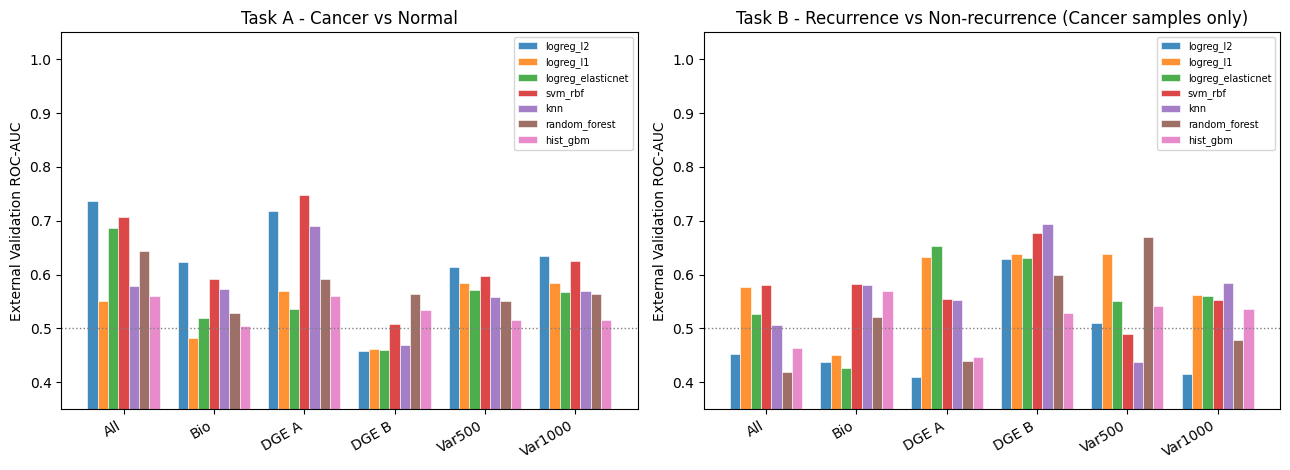

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
palette = plt.cm.tab10.colors

model_names = list(build_models(None).keys())
n_models = len(model_names)
bar_width = 0.8 / n_models  # total bar group width = 0.8

for ax, rows, title in [
    (ax1, rows_A, "Task A - Cancer vs Normal"),
    (ax2, rows_B, "Task B - Recurrence vs Non-recurrence (Cancer samples only)"),
]:
    labels = [r["label"] for r in rows]
    x = np.arange(len(labels))

    for i, name in enumerate(model_names):
        aucs = [r.get(f"auc_{name}", np.nan) for r in rows]
        offset = (i - n_models / 2 + 0.5) * bar_width
        ax.bar(x + offset, aucs, width=bar_width, label=name,
               color=palette[i], alpha=0.85, edgecolor="white", linewidth=0.5)

    ax.axhline(0.5, color="grey", linestyle=":", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0.35, 1.05)
    ax.set_ylabel("External Validation ROC-AUC")
    ax.set_title(title)
    ax.legend(fontsize=7, loc="upper right")

fig.tight_layout()
fig.savefig(RESULTS / "feature_selection_comparison.png", dpi=300, bbox_inches="tight")
plt.show()